In [1]:
import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm.auto import tqdm

# locate the attached dataset
def find_variant(long_edge: int) -> Path:
    hits = []
    for prov in Path("/kaggle/input").rglob("provenance.json"):
        try:
            meta = json.loads(prov.read_text())
        except Exception:
            continue
        if meta.get("transform", {}).get("long_edge_px") == long_edge:
            hits.append(prov.parent)
    if not hits:
        found = sorted(p.parent.name for p in Path("/kaggle/input").rglob("provenance.json"))
        raise RuntimeError(f"no variant at {long_edge}px. found: {found}")
    return hits[0]

DATA = find_variant(1024)
print("data:", DATA)

labels = pd.read_csv(DATA / "microscopist_result.csv")
labels.columns = [c.strip() for c in labels.columns]

def _to_bin(v):
    s = str(v).strip().lower()
    if s.startswith("p") or s in {"1", "1.0", "true", "yes"}: return 1
    if s.startswith("n") or s in {"0", "0.0", "false", "no"}: return 0
    raise ValueError(v)

labels["y"] = labels["diagnosis"].map(_to_bin)
labels = labels.sort_values("sample_id").reset_index(drop=True)

SAMPLES = labels["sample_id"].astype(str).tolist()
Y = labels["y"].to_numpy()

assert len(SAMPLES) == 65 and Y.sum() == 32
for sid in SAMPLES:
    n = len(list((DATA / sid).glob("*.jpg")))
    assert n == 117, f"{sid} has {n} images"

print(f"{len(SAMPLES)} samples — {Y.sum()} positive, {(Y==0).sum()} negative")
print(f"low-burden positives (<=5 eggs): {int(((labels.y==1) & (labels.egg_count<=5)).sum())}")

# device 
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "|", torch.cuda.get_device_name(0) if DEV == "cuda" else "")
assert DEV == "cuda", "turn on the GPU accelerator in the sidebar"

data: /kaggle/input/notebooks/oglorypaul/00-mirror-diagnosis-dataset/bilharz-diagnosis-65
65 samples — 32 positive, 33 negative
low-burden positives (<=5 eggs): 9
device: cuda | Tesla T4


In [2]:
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# 1024x767 -> 512x384 keeps the aspect ratio exactly (1.335 vs 1.333),
# so the whole field of view is preserved with no distortion and no cropping.
TF = transforms.Compose([
    transforms.Resize((384, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class BagImages(Dataset):
    """Every image of every sample, in a fixed, reproducible order."""
    def __init__(self, root: Path, sample_ids):
        self.items = []
        for sid in sample_ids:
            for p in sorted((root / sid).glob("*.jpg")):
                self.items.append((sid, p))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        sid, p = self.items[i]
        with Image.open(p) as im:
            x = TF(im.convert("RGB"))
        return x, sid, p.name

ds = BagImages(DATA, SAMPLES)
assert len(ds) == 7605
dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# frozen ImageNet ResNet50, cut before the classifier
net = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
backbone = nn.Sequential(*list(net.children())[:-2]).to(DEV).eval()
for p in backbone.parameters():
    p.requires_grad = False

@torch.no_grad()
def embed(batch):
    """Average- AND max-pool the feature map, concatenated -> 4096-d.

    Average pooling alone dilutes a small bright object across a 12x16 grid;
    max pooling keeps the strongest local response, which is what an egg is.
    """
    with torch.autocast("cuda", dtype=torch.float16):
        fm = backbone(batch)                      # (B, 2048, 12, 16)
    fm = fm.float()
    avg = fm.mean(dim=(2, 3))
    mx  = fm.amax(dim=(2, 3))
    return torch.cat([avg, mx], dim=1)            # (B, 4096)

vecs, sids, fnames = [], [], []
t0 = time.time()
for xb, sb, fb in tqdm(dl, desc="embed"):
    vecs.append(embed(xb.to(DEV, non_blocking=True)).cpu())
    sids.extend(sb); fnames.extend(fb)

E = torch.cat(vecs).numpy().astype(np.float32)
print(f"\n{E.shape} in {time.time()-t0:.0f}s")

#  reshape into bags, preserving image order 
D = E.shape[1]
idx = {sid: i for i, sid in enumerate(SAMPLES)}
BAGS  = np.zeros((len(SAMPLES), 117, D), dtype=np.float32)
FILES = np.empty((len(SAMPLES), 117), dtype=object)

cursor = {sid: 0 for sid in SAMPLES}
for row, (sid, fn) in enumerate(zip(sids, fnames)):
    k = cursor[sid]
    BAGS[idx[sid], k] = E[row]
    FILES[idx[sid], k] = fn
    cursor[sid] = k + 1

assert all(v == 117 for v in cursor.values())
assert not np.isnan(BAGS).any()

np.savez_compressed(
    "/kaggle/working/bags_resnet50_384x512.npz",
    bags=BAGS, y=Y, sample_ids=np.array(SAMPLES), files=FILES,
    egg_count=labels["egg_count"].to_numpy(),
)
print(f"bags {BAGS.shape}  labels {Y.shape}  saved")
print(f"mean activation {BAGS.mean():.3f}  std {BAGS.std():.3f}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


embed:   0%|          | 0/238 [00:00<?, ?it/s]


(7605, 4096) in 98s
bags (65, 117, 4096)  labels (65,)  saved
mean activation 0.585  std 1.862


In [3]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)

class GatedAttentionMIL(nn.Module):
    """Ilse et al. (2018). Attention weights are returned, not just the logit —
    they are what tells a reviewer which of the 117 images to open."""
    def __init__(self, d_in=4096, d=256, d_att=128, p_drop=0.25):
        super().__init__()
        self.feat  = nn.Sequential(nn.LayerNorm(d_in), nn.Linear(d_in, d),
                                   nn.ReLU(), nn.Dropout(p_drop))
        self.att_V = nn.Sequential(nn.Linear(d, d_att), nn.Tanh())
        self.att_U = nn.Sequential(nn.Linear(d, d_att), nn.Sigmoid())
        self.att_w = nn.Linear(d_att, 1)
        self.head  = nn.Linear(d, 1)

    def forward(self, bags):                       # (B, N, d_in)
        h = self.feat(bags)                        # (B, N, d)
        a = self.att_w(self.att_V(h) * self.att_U(h))
        a = torch.softmax(a, dim=1)                # (B, N, 1)
        z = (a * h).sum(dim=1)                     # (B, d)
        return self.head(z).squeeze(-1), a.squeeze(-1)

def fit_mil(Xtr, ytr, Xte, epochs=60, lr=3e-4, wd=1e-4, seed=0):
    torch.manual_seed(seed)
    m = GatedAttentionMIL(d_in=Xtr.shape[-1]).to(DEV)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()
    xb = torch.tensor(Xtr, device=DEV); yb = torch.tensor(ytr, dtype=torch.float32, device=DEV)
    m.train()
    for _ in range(epochs):
        opt.zero_grad()
        logit, _ = m(xb)
        lossf(logit, yb).backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        logit, att = m(torch.tensor(Xte, device=DEV))
        return torch.sigmoid(logit).cpu().numpy(), att.cpu().numpy()

N_REPEATS = 5
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=N_REPEATS, random_state=SEED)

oof = {k: np.zeros((N_REPEATS, len(Y))) for k in ["mil", "mean", "max"]}
att_store = np.zeros((N_REPEATS, len(Y), 117))

MEANB = BAGS.mean(axis=1)      # mean-pooled bag vectors
MAXB  = BAGS.max(axis=1)       # max-pooled bag vectors

for f, (tr, te) in enumerate(tqdm(list(cv.split(BAGS, Y)), desc="cv")):
    r = f // 5
    # every split is on SAMPLES, never on images — no patient is ever
    # partly in train and partly in test
    p, a = fit_mil(BAGS[tr], Y[tr], BAGS[te], seed=SEED + f)
    oof["mil"][r, te] = p
    att_store[r, te] = a

    for name, M in (("mean", MEANB), ("max", MAXB)):
        sc = StandardScaler().fit(M[tr])
        lr_ = LogisticRegression(max_iter=2000, C=1.0).fit(sc.transform(M[tr]), Y[tr])
        oof[name][r, te] = lr_.predict_proba(sc.transform(M[te]))[:, 1]

np.savez_compressed("/kaggle/working/oof_predictions.npz",
                    y=Y, sample_ids=np.array(SAMPLES),
                    egg_count=labels["egg_count"].to_numpy(),
                    att=att_store, **{f"oof_{k}": v for k, v in oof.items()})

for k, v in oof.items():
    print(f"{k:5s}  mean prob on positives {v[:, Y==1].mean():.3f}   "
          f"on negatives {v[:, Y==0].mean():.3f}")

cv:   0%|          | 0/25 [00:00<?, ?it/s]

mil    mean prob on positives 0.696   on negatives 0.330
mean   mean prob on positives 0.672   on negatives 0.353
max    mean prob on positives 0.684   on negatives 0.318


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

LOWB = (Y == 1) & (labels["egg_count"].to_numpy() <= 5)   # the 9 hard positives
HIGHB = (Y == 1) & (labels["egg_count"].to_numpy() > 5)

def spec_at_sens(y, p, target=0.90):
    """Lowest threshold that still catches `target` of the positives,
    then the specificity you pay for it."""
    fpr, tpr, thr = roc_curve(y, p)
    ok = tpr >= target
    if not ok.any():
        return np.nan
    return 1 - fpr[ok][0]

def score(y, p, thresh=0.5):
    pred = (p >= thresh).astype(int)
    return {
        "AUROC":      roc_auc_score(y, p),
        "AP":         average_precision_score(y, p),
        "Sens@0.5":   pred[y == 1].mean(),
        "Spec@0.5":   1 - pred[y == 0].mean(),
        "Spec@90Sens": spec_at_sens(y, p, 0.90),
        "Sens low-burden":  pred[LOWB].mean(),
        "Sens high-burden": pred[HIGHB].mean(),
    }

rows = []
for name in ["mil", "max", "mean"]:
    per_repeat = [score(Y, oof[name][r]) for r in range(N_REPEATS)]
    df = pd.DataFrame(per_repeat)
    rows.append(pd.Series({c: f"{df[c].mean():.3f} ± {df[c].std():.3f}"
                           for c in df.columns}, name=name))

results = pd.DataFrame(rows)
print(results.to_string())
print(f"\nn = {len(Y)}  ({Y.sum()} positive, {(Y==0).sum()} negative)")
print(f"low-burden positives (<=5 eggs): {LOWB.sum()}   high-burden: {HIGHB.sum()}")

              AUROC             AP       Sens@0.5       Spec@0.5    Spec@90Sens Sens low-burden Sens high-burden
mil   0.744 ± 0.039  0.731 ± 0.034  0.681 ± 0.041  0.673 ± 0.040  0.442 ± 0.165   0.511 ± 0.127    0.748 ± 0.048
max   0.739 ± 0.023  0.714 ± 0.030  0.731 ± 0.042  0.727 ± 0.043  0.333 ± 0.043   0.556 ± 0.000    0.800 ± 0.058
mean  0.721 ± 0.023  0.676 ± 0.037  0.675 ± 0.036  0.655 ± 0.035  0.406 ± 0.059   0.533 ± 0.050    0.730 ± 0.048

n = 65  (32 positive, 33 negative)
low-burden positives (<=5 eggs): 9   high-burden: 23


In [5]:
TILE_ROWS, TILE_COLS = 3, 4
N_TILES = TILE_ROWS * TILE_COLS
TILE_PX = 256

TF_TILE = transforms.Compose([
    transforms.Resize((TILE_PX, TILE_PX)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class TiledImages(Dataset):
    """One item = one field of view, returned as its 12 tiles."""
    def __init__(self, root: Path, sample_ids):
        self.items = []
        for sid in sample_ids:
            for p in sorted((root / sid).glob("*.jpg")):
                self.items.append((sid, p))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        sid, p = self.items[i]
        with Image.open(p) as im:
            im = im.convert("RGB")
            W, H = im.size
            tw, th = W // TILE_COLS, H // TILE_ROWS
            tiles = [TF_TILE(im.crop((c*tw, r*th, (c+1)*tw, (r+1)*th)))
                     for r in range(TILE_ROWS) for c in range(TILE_COLS)]
        return torch.stack(tiles), sid, p.name

ds_t = TiledImages(DATA, SAMPLES)
dl_t = DataLoader(ds_t, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

vecs, sids, fnames = [], [], []
t0 = time.time()
for xb, sb, fb in tqdm(dl_t, desc="embed tiles"):
    B = xb.shape[0]
    flat = xb.view(B * N_TILES, 3, TILE_PX, TILE_PX).to(DEV, non_blocking=True)
    e = embed(flat).view(B, N_TILES, -1).cpu()     # (B, 12, 4096)
    vecs.append(e); sids.extend(sb); fnames.extend(fb)

ET = torch.cat(vecs).numpy().astype(np.float16)    # (7605, 12, 4096)
print(f"\n{ET.shape} in {time.time()-t0:.0f}s")

#  assemble bags: 117 images x 12 tiles = 1404 instances per patient 
D = ET.shape[-1]
BAGS_T = np.zeros((len(SAMPLES), 117 * N_TILES, D), dtype=np.float16)
INST   = np.empty((len(SAMPLES), 117 * N_TILES), dtype=object)

cursor = {sid: 0 for sid in SAMPLES}
for row, (sid, fn) in enumerate(zip(sids, fnames)):
    k = cursor[sid]
    s = idx[sid]
    BAGS_T[s, k*N_TILES:(k+1)*N_TILES] = ET[row]
    for t in range(N_TILES):
        INST[s, k*N_TILES + t] = f"{fn}#{t}"       # keeps tile -> image mapping
    cursor[sid] = k + 1

assert all(v == 117 for v in cursor.values())
assert not np.isnan(BAGS_T.astype(np.float32)).any()

np.savez_compressed("/kaggle/working/bags_tiled_3x4.npz",
                    bags=BAGS_T, y=Y, sample_ids=np.array(SAMPLES),
                    inst=INST, egg_count=labels["egg_count"].to_numpy())

print(f"bags {BAGS_T.shape}  ({BAGS_T.nbytes/1e9:.2f} GB as float16)")

embed tiles:   0%|          | 0/951 [00:00<?, ?it/s]


(7605, 12, 4096) in 187s
bags (65, 1404, 4096)  (0.75 GB as float16)


In [6]:
# bags are float16 to save memory; cast per fold on the GPU
def fit_mil_t(Xtr, ytr, Xte, epochs=60, lr=3e-4, wd=1e-4, seed=0):
    torch.manual_seed(seed)
    m = GatedAttentionMIL(d_in=Xtr.shape[-1]).to(DEV)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()
    xb = torch.from_numpy(Xtr).to(DEV).float()
    yb = torch.tensor(ytr, dtype=torch.float32, device=DEV)
    m.train()
    for _ in range(epochs):
        opt.zero_grad()
        logit, _ = m(xb)
        lossf(logit, yb).backward()
        opt.step()
    m.eval()
    del xb
    with torch.no_grad():
        xt = torch.from_numpy(Xte).to(DEV).float()
        logit, att = m(xt)
        out = torch.sigmoid(logit).cpu().numpy(), att.cpu().numpy()
    del xt; torch.cuda.empty_cache()
    return out

N_INST = BAGS_T.shape[1]
MEANB_T = BAGS_T.mean(axis=1, dtype=np.float32)
MAXB_T  = BAGS_T.astype(np.float32).max(axis=1)

oof_t = {k: np.zeros((N_REPEATS, len(Y))) for k in ["mil", "mean", "max"]}
att_t = np.zeros((N_REPEATS, len(Y), N_INST), dtype=np.float32)

for f, (tr, te) in enumerate(tqdm(list(cv.split(BAGS_T, Y)), desc="cv tiled")):
    r = f // 5
    p, a = fit_mil_t(BAGS_T[tr], Y[tr], BAGS_T[te], seed=SEED + f)
    oof_t["mil"][r, te] = p
    att_t[r, te] = a
    for name, M in (("mean", MEANB_T), ("max", MAXB_T)):
        sc = StandardScaler().fit(M[tr])
        lr_ = LogisticRegression(max_iter=2000, C=1.0).fit(sc.transform(M[tr]), Y[tr])
        oof_t[name][r, te] = lr_.predict_proba(sc.transform(M[te]))[:, 1]

np.savez_compressed("/kaggle/working/oof_tiled.npz",
                    y=Y, sample_ids=np.array(SAMPLES),
                    egg_count=labels["egg_count"].to_numpy(),
                    att=att_t.astype(np.float16),
                    **{f"oof_{k}": v for k, v in oof_t.items()})

rows = []
for name in ["mil", "max", "mean"]:
    df = pd.DataFrame([score(Y, oof_t[name][r]) for r in range(N_REPEATS)])
    rows.append(pd.Series({c: f"{df[c].mean():.3f} ± {df[c].std():.3f}"
                           for c in df.columns}, name=name))
print("\nTILED (1404 instances/bag)")
print(pd.DataFrame(rows).to_string())

print("\nAUROC, whole-frame -> tiled")
for name in ["mil", "max", "mean"]:
    a = np.mean([roc_auc_score(Y, oof[name][r])   for r in range(N_REPEATS)])
    b = np.mean([roc_auc_score(Y, oof_t[name][r]) for r in range(N_REPEATS)])
    print(f"  {name:5s} {a:.3f} -> {b:.3f}   ({b-a:+.3f})")

cv tiled:   0%|          | 0/25 [00:00<?, ?it/s]


TILED (1404 instances/bag)
              AUROC             AP       Sens@0.5       Spec@0.5    Spec@90Sens Sens low-burden Sens high-burden
mil   0.631 ± 0.030  0.606 ± 0.029  0.613 ± 0.068  0.606 ± 0.074  0.248 ± 0.084   0.511 ± 0.061    0.652 ± 0.081
max   0.759 ± 0.022  0.737 ± 0.050  0.731 ± 0.052  0.679 ± 0.017  0.461 ± 0.108   0.644 ± 0.093    0.765 ± 0.050
mean  0.681 ± 0.024  0.674 ± 0.046  0.650 ± 0.034  0.636 ± 0.064  0.285 ± 0.070   0.489 ± 0.061    0.713 ± 0.050

AUROC, whole-frame -> tiled
  mil   0.744 -> 0.631   (-0.113)
  max   0.739 -> 0.759   (+0.020)
  mean  0.721 -> 0.681   (-0.040)


In [7]:
A = att_t.astype(np.float64) + 1e-12
H = -(A * np.log(A)).sum(axis=2)            # entropy of each bag's attention
eff = np.exp(H)                              # effective number of instances attended
print(f"instances per bag: {att_t.shape[2]}")
print(f"effective instances attended: {eff.mean():.0f}  "
      f"(min {eff.min():.0f}, max {eff.max():.0f})")
print(f"fraction of bag effectively used: {eff.mean()/att_t.shape[2]:.1%}")
print(f"mean of top-10 weights: {np.sort(A, axis=2)[:, :, -10:].mean():.5f}  "
      f"vs uniform {1/att_t.shape[2]:.5f}")

instances per bag: 1404
effective instances attended: 160  (min 5, max 1124)
fraction of bag effectively used: 11.4%
mean of top-10 weights: 0.05005  vs uniform 0.00071


In [8]:
import matplotlib.pyplot as plt

K_VALUES = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1404]
D = BAGS_T.shape[-1]
N_INST = BAGS_T.shape[1]

def fit_instance_scorer(Xb, yb, epochs=200, lr=1e-3, wd=1e-4, seed=0):
    """Score tiles individually. Bag labels are copied to every tile inside the
    bag — crude for positives (most of their tiles hold no egg) but exact for
    negatives, which is enough to learn what 'nothing here' looks like."""
    torch.manual_seed(seed)
    B, N, Dd = Xb.shape
    X = torch.from_numpy(Xb.reshape(B * N, Dd)).to(DEV).float()
    yv = torch.tensor(np.repeat(yb, N), dtype=torch.float32, device=DEV)
    lin = nn.Sequential(nn.LayerNorm(Dd), nn.Linear(Dd, 1)).to(DEV)
    opt = torch.optim.AdamW(lin.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()
    lin.train()
    for _ in range(epochs):
        opt.zero_grad()
        lossf(lin(X).squeeze(-1), yv).backward()
        opt.step()
    del X, yv; torch.cuda.empty_cache()
    return lin.eval()

topk = np.zeros((N_REPEATS, len(Y), len(K_VALUES)))

for f, (tr, te) in enumerate(tqdm(list(cv.split(BAGS_T, Y)), desc="top-k")):
    r = f // 5
    lin = fit_instance_scorer(BAGS_T[tr], Y[tr], seed=SEED + f)
    with torch.no_grad():
        Xt = torch.from_numpy(BAGS_T[te].reshape(-1, D)).to(DEV).float()
        p = torch.sigmoid(lin(Xt).squeeze(-1)).view(len(te), N_INST).cpu().numpy()
        del Xt; torch.cuda.empty_cache()
    srt = np.sort(p, axis=1)[:, ::-1]                 # tiles, most suspicious first
    for ki, k in enumerate(K_VALUES):
        topk[r, te, ki] = srt[:, :k].mean(axis=1)

np.savez_compressed("/kaggle/working/topk_sweep.npz",
                    y=Y, k_values=np.array(K_VALUES), topk=topk)

rows = []
for ki, k in enumerate(K_VALUES):
    s90 = [spec_at_sens(Y, topk[r, :, ki], 0.90) for r in range(N_REPEATS)]
    s80 = [spec_at_sens(Y, topk[r, :, ki], 0.80) for r in range(N_REPEATS)]
    auc = [roc_auc_score(Y, topk[r, :, ki])      for r in range(N_REPEATS)]
    rows.append({"k": k,
                 "AUROC": np.mean(auc),  "AUROC_sd": np.std(auc),
                 "Spec@90Sens": np.mean(s90), "Spec@90_sd": np.std(s90),
                 "Spec@80Sens": np.mean(s80), "Spec@80_sd": np.std(s80)})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

top-k:   0%|          | 0/25 [00:00<?, ?it/s]

   k  AUROC  AUROC_sd  Spec@90Sens  Spec@90_sd  Spec@80Sens  Spec@80_sd
   1  0.741     0.025        0.376       0.091        0.636       0.051
   2  0.742     0.025        0.358       0.089        0.576       0.064
   3  0.745     0.024        0.345       0.080        0.570       0.062
   5  0.744     0.024        0.339       0.067        0.558       0.083
  10  0.748     0.022        0.345       0.056        0.564       0.073
  20  0.746     0.021        0.376       0.062        0.564       0.080
  50  0.743     0.023        0.400       0.065        0.570       0.073
 100  0.739     0.023        0.442       0.041        0.588       0.049
 200  0.734     0.023        0.455       0.033        0.606       0.051
 500  0.720     0.019        0.479       0.030        0.600       0.052
1404  0.714     0.020        0.382       0.071        0.576       0.069


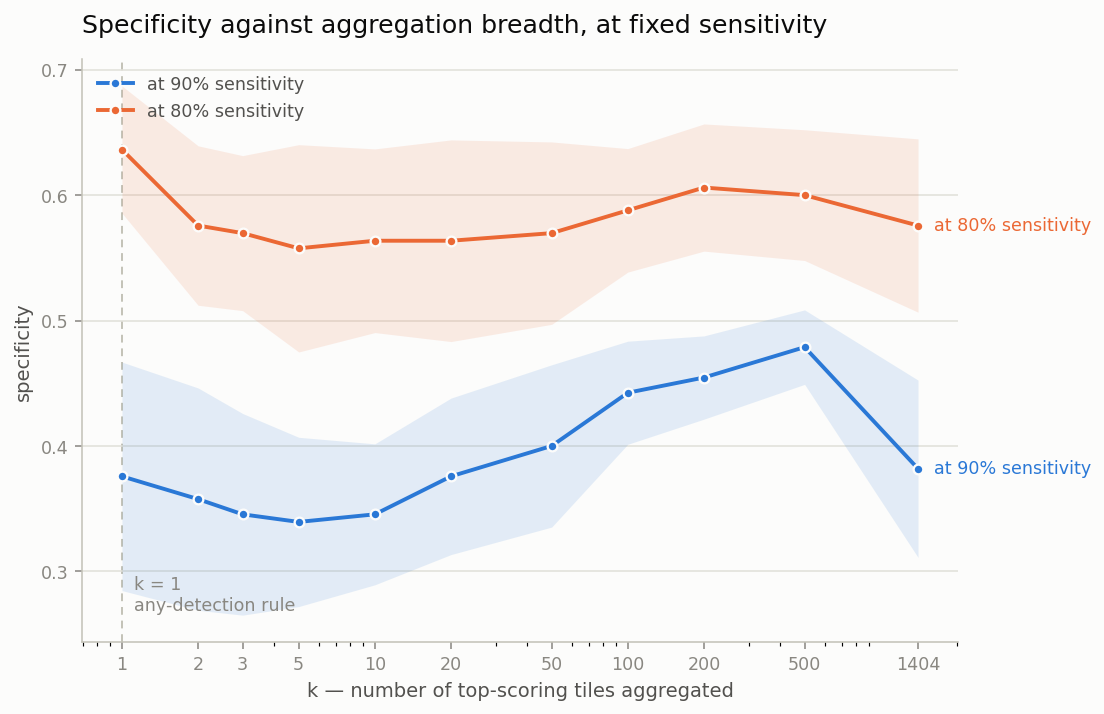

saved fig_topk_specificity.png


In [9]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
S1, S2 = "#2a78d6", "#eb6834"

fig, ax = plt.subplots(figsize=(9, 5.4), dpi=140)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

k = sweep["k"].to_numpy()
for col, sd, color, label in [("Spec@90Sens", "Spec@90_sd", S1, "at 90% sensitivity"),
                              ("Spec@80Sens", "Spec@80_sd", S2, "at 80% sensitivity")]:
    m, s = sweep[col].to_numpy(), sweep[sd].to_numpy()
    ax.fill_between(k, m - s, m + s, color=color, alpha=0.12, linewidth=0)
    ax.plot(k, m, color=color, linewidth=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.2, label=label)
    ax.annotate(label, (k[-1], m[-1]), xytext=(8, 0), textcoords="offset points",
                color=color, fontsize=9, va="center")

ax.axvline(1, color=AXIS, linewidth=1, linestyle=(0, (4, 3)), zorder=0)
ax.annotate("k = 1\nany-detection rule", (1, ax.get_ylim()[0]), xytext=(6, 14),
            textcoords="offset points", color=MUTED, fontsize=9, va="bottom")

ax.set_xscale("log")
ax.set_xticks(K_VALUES); ax.set_xticklabels([str(v) for v in K_VALUES])
ax.set_xlabel("k — number of top-scoring tiles aggregated", color="#52514e", fontsize=10)
ax.set_ylabel("specificity", color="#52514e", fontsize=10)
ax.set_title("Specificity against aggregation breadth, at fixed sensitivity",
             color=INK, fontsize=13, pad=14, loc="left")
ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
for s_ in ("left", "bottom"): ax.spines[s_].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="upper left", fontsize=9, labelcolor="#52514e")
plt.subplots_adjust(right=0.82)
plt.savefig("/kaggle/working/fig_topk_specificity.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()
print("saved fig_topk_specificity.png")

In [10]:
from pathlib import Path
for p in sorted(Path("/kaggle/working").rglob("*")):
    if p.is_file():
        print(f"{p.stat().st_size/1e6:8.1f} MB  {p.name}")

     0.2 MB  __notebook__.ipynb
    48.5 MB  bags_resnet50_384x512.npz
   330.6 MB  bags_tiled_3x4.npz
     0.1 MB  fig_topk_specificity.png
     0.2 MB  oof_predictions.npz
     0.8 MB  oof_tiled.npz
     0.0 MB  topk_sweep.npz


## Infection burden across the cohort

The 65 samples split almost evenly — 32 positive, 33 negative — but the positives
are not alike. Expert egg counts range from 1 to 516, and nine of the 32 positives
contain five eggs or fewer.

That subgroup is where the aggregation rule decides the outcome. In a heavy
infection almost any rule finds the parasite; in a low-burden sample, one missed or
spurious detection among 117 images flips the patient-level verdict. The shaded
band marks it.

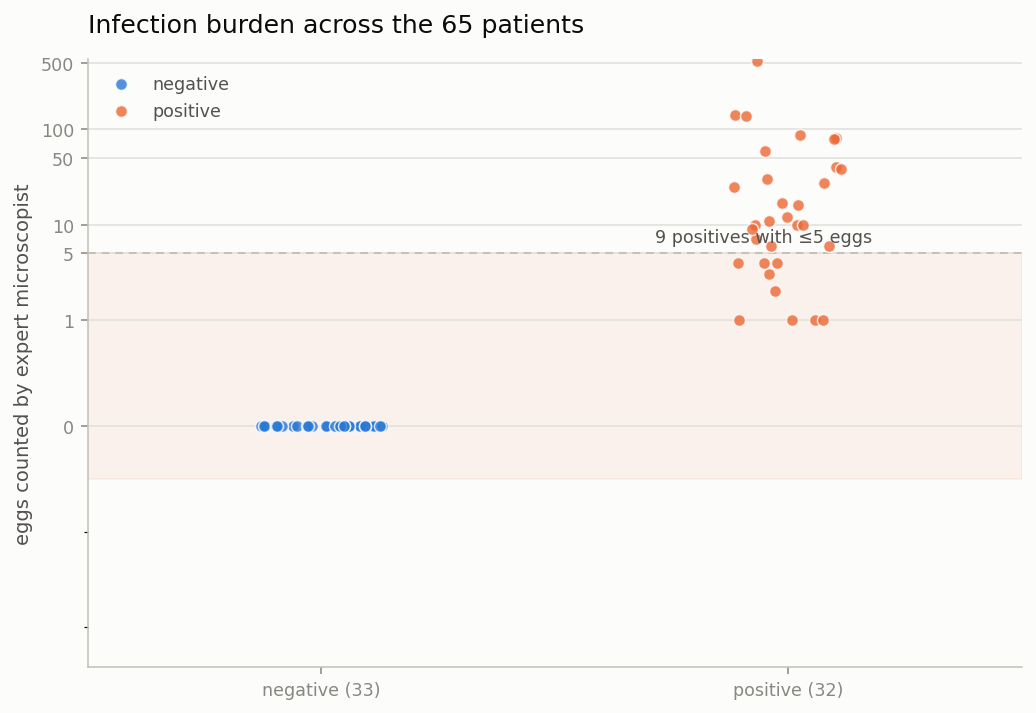

In [11]:
import matplotlib.pyplot as plt

SURFACE, INK, SEC, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
S1, S2 = "#2a78d6", "#eb6834"

rng = np.random.default_rng(0)
ec = labels["egg_count"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 5.2), dpi=140)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

ax.axhspan(-0.5, 5, color=S2, alpha=0.07, zorder=0)

for xpos, mask, color, name in [(0, Y == 0, S1, "negative"), (1, Y == 1, S2, "positive")]:
    xs = xpos + rng.uniform(-0.13, 0.13, mask.sum())
    ax.scatter(xs, ec[mask], s=38, color=color, alpha=0.8,
               edgecolor=SURFACE, linewidth=0.8, label=name, zorder=3)

ax.axhline(5, color=AXIS, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.annotate(f"{int(((Y==1) & (ec<=5)).sum())} positives with ≤5 eggs",
            (1.18, 5), xytext=(0, 6), textcoords="offset points",
            color=SEC, fontsize=9, ha="right")

ax.set_yscale("symlog", linthresh=1)
ax.set_yticks([0, 1, 5, 10, 50, 100, 500])
ax.set_yticklabels(["0", "1", "5", "10", "50", "100", "500"])
ax.set_xticks([0, 1]); ax.set_xticklabels(["negative (33)", "positive (32)"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("eggs counted by expert microscopist", color=SEC, fontsize=10)
ax.set_title("Infection burden across the 65 patients", color=INK, fontsize=13, pad=14, loc="left")
ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
for s_ in ("left", "bottom"): ax.spines[s_].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="upper left", fontsize=9, labelcolor=SEC)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_egg_burden.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()

## What one instance looks like

Each patient is represented by 117 field-of-view images across the filter membrane.
The model never sees a whole sample at once — it sees these frames.

Most frames contain no egg at all, even for a heavily infected patient, so the
positive signal is sparse within a bag. The frames also contain abundant
non-parasite structure — fibres, debris, membrane texture, out-of-focus regions —
which is what an attention mechanism can mistakenly latch onto.

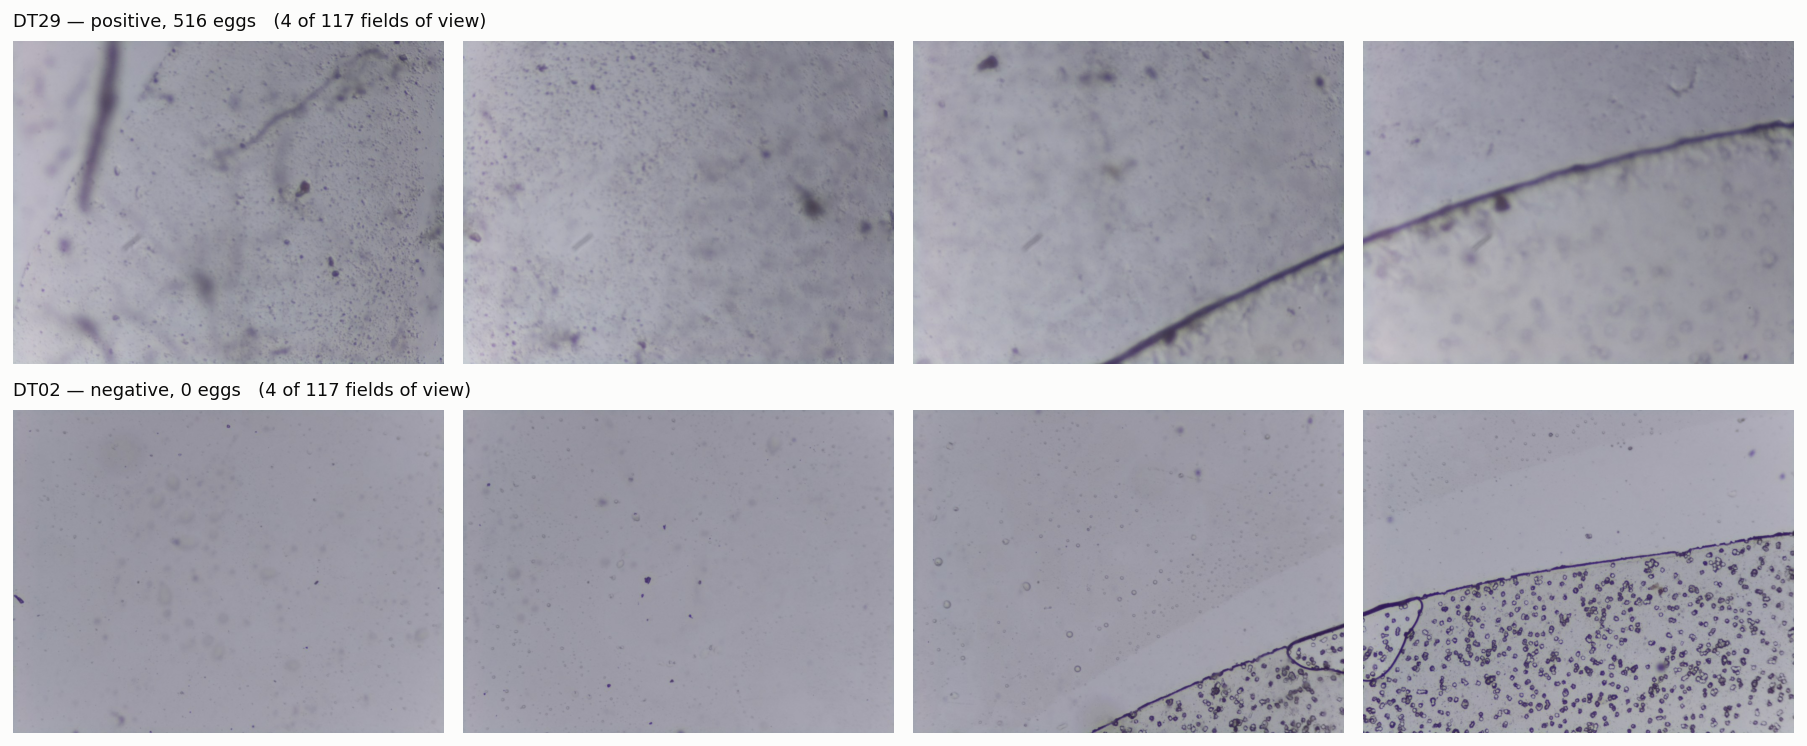

In [12]:
pos_id = str(labels.loc[labels.egg_count.idxmax(), "sample_id"])
neg_id = str(labels[labels.y == 0].iloc[0]["sample_id"])

fig, axes = plt.subplots(2, 4, figsize=(14, 6), dpi=130)
fig.patch.set_facecolor(SURFACE)

for row, (sid, tag, count) in enumerate([
        (pos_id, "positive", int(labels.loc[labels.sample_id == pos_id, "egg_count"].iloc[0])),
        (neg_id, "negative", int(labels.loc[labels.sample_id == neg_id, "egg_count"].iloc[0]))]):
    paths = sorted((DATA / sid).glob("*.jpg"))[:4]
    for col, p in enumerate(paths):
        with Image.open(p) as im:
            axes[row, col].imshow(im)
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"{sid} — {tag}, {count} eggs   (4 of 117 fields of view)",
                           loc="left", fontsize=10, color=INK, pad=8)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_fov_examples.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

## Effect of instance granularity

The two representations differ in one variable only: 117 whole-frame instances per
patient versus 1,404 tiled ones. Folds, seeds, model and baselines are identical,
so any difference is attributable to granularity alone.

The result separates the methods rather than lifting them together. Max-pooling
improves; mean-pooling and attention MIL both degrade. Finer tiles make a single
egg occupy a far larger share of its own instance, rewarding an operator that
selects the strongest response and penalising any operator that averages across the
bag — evidence that the diagnostic signal is extreme-valued rather than distributed.

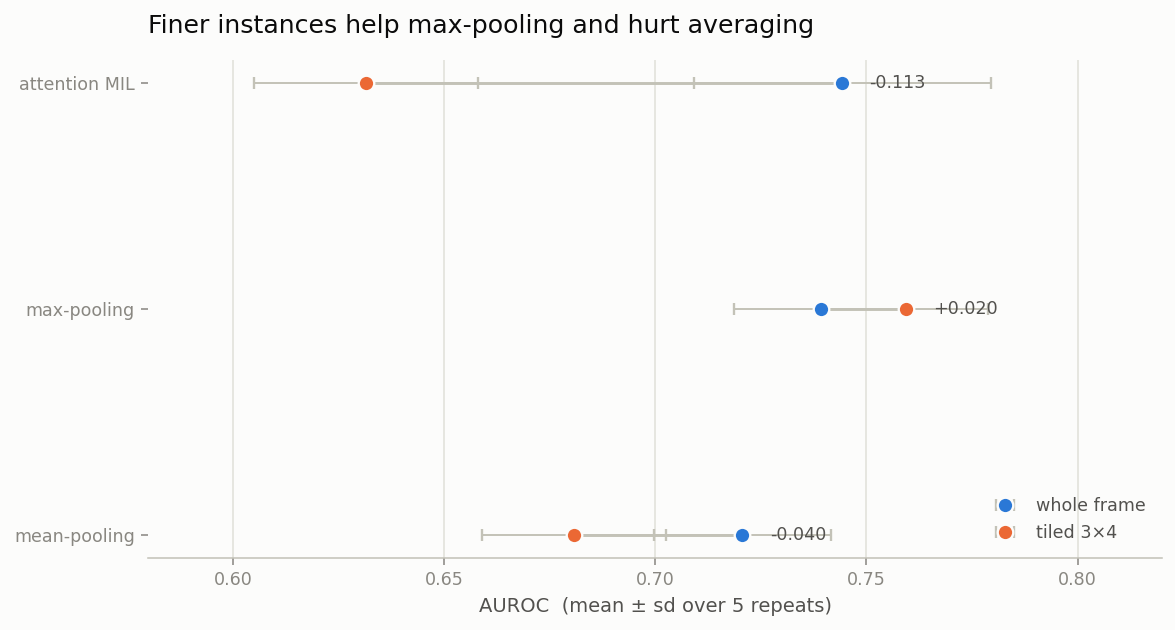

In [13]:
methods = [("mil", "attention MIL"), ("max", "max-pooling"), ("mean", "mean-pooling")]
rows = []
for key, name in methods:
    a = [roc_auc_score(Y, oof[key][r])   for r in range(N_REPEATS)]
    b = [roc_auc_score(Y, oof_t[key][r]) for r in range(N_REPEATS)]
    rows.append((name, np.mean(a), np.std(a), np.mean(b), np.std(b)))

fig, ax = plt.subplots(figsize=(8.5, 4.6), dpi=140)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

for i, (name, am, asd, bm, bsd) in enumerate(rows):
    y = len(rows) - 1 - i
    ax.plot([am, bm], [y, y], color=AXIS, linewidth=1.5, zorder=1)
    ax.errorbar(am, y, xerr=asd, fmt="o", color=S1, markersize=8, capsize=3,
                ecolor=AXIS, elinewidth=1, markeredgecolor=SURFACE,
                markeredgewidth=1.2, zorder=3, label="whole frame" if i == 0 else None)
    ax.errorbar(bm, y, xerr=bsd, fmt="o", color=S2, markersize=8, capsize=3,
                ecolor=AXIS, elinewidth=1, markeredgecolor=SURFACE,
                markeredgewidth=1.2, zorder=3, label="tiled 3×4" if i == 0 else None)
    ax.annotate(f"{bm-am:+.3f}", (max(am, bm), y), xytext=(14, 0),
                textcoords="offset points", color=SEC, fontsize=9, va="center")

ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows][::-1], fontsize=10)
ax.set_xlabel("AUROC  (mean ± sd over 5 repeats)", color=SEC, fontsize=10)
ax.set_title("Finer instances help max-pooling and hurt averaging",
             color=INK, fontsize=13, pad=14, loc="left")
ax.set_xlim(0.58, 0.82)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
for s_ in ("top", "right", "left"): ax.spines[s_].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="lower right", fontsize=9, labelcolor=SEC)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_frame_vs_tiled.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()